In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
print(os.listdir('/content/drive/MyDrive/CAPSTONE_DATA'))

['youtube', 'twitter', 'reddit', 'outputs']


In [3]:
print(os.listdir('/content/drive/MyDrive/CAPSTONE_DATA/twitter'))

['final_twitter_matched.csv', 'twitter_matched_users.csv', 'twitter_brand_profiles.csv', 'twitter_sponsorship_events.csv', 'final_twitter_brands.csv']


In [5]:
!pip install vaderSentiment pandas matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import os

analyzer = SentimentIntensityAnalyzer()
os.makedirs('/content/drive/MyDrive/CAPSTONE_DATA/outputs', exist_ok=True)
print(" Ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.1 MB/s eta 0:00:00
 Ready!


In [6]:
tw_matched = pd.read_csv('/content/drive/MyDrive/CAPSTONE_DATA/twitter/final_twitter_matched.csv')
tw_brands = pd.read_csv('/content/drive/MyDrive/CAPSTONE_DATA/twitter/final_twitter_brands.csv')

print(f"Influencer tweets: {tw_matched.shape}")
print(f"Brand tweets: {tw_brands.shape}")

Influencer tweets: (239, 13)
Brand tweets: (173, 14)


In [8]:
tw_matched = tw_matched.dropna(subset=['text'])
tw_matched = tw_matched[tw_matched['text'].str.strip() != '']
tw_matched['text'] = tw_matched['text'].astype(str)
tw_matched['source'] = 'influencer'

tw_brands = tw_brands.dropna(subset=['text'])
tw_brands = tw_brands[tw_brands['text'].str.strip() != '']
tw_brands['text'] = tw_brands['text'].astype(str)
tw_brands['source'] = 'brand'

print(f" Influencer tweets clean: {len(tw_matched)}")
print(f" Brand tweets clean: {len(tw_brands)}")

 Influencer tweets clean: 239
 Brand tweets clean: 173


In [9]:
def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        label = 'positive'
    elif compound <= -0.05:
        label = 'negative'
    else:
        label = 'neutral'
    return pd.Series([compound, label, scores['pos'], scores['neg'], scores['neu']])

tw_matched[['compound', 'sentiment', 'pos', 'neg', 'neu']] = tw_matched['text'].apply(get_sentiment)
tw_brands[['compound', 'sentiment', 'pos', 'neg', 'neu']] = tw_brands['text'].apply(get_sentiment)

print("Sentiment done!")
print("\nInfluencer sentiment:")
print(tw_matched['sentiment'].value_counts())
print("\nBrand sentiment:")
print(tw_brands['sentiment'].value_counts())

Sentiment done!

Influencer sentiment:
sentiment
positive    130
neutral      81
negative     28
Name: count, dtype: int64

Brand sentiment:
sentiment
positive    74
neutral     71
negative    28
Name: count, dtype: int64


In [10]:
tw_brands['brand_safety_flag'] = tw_brands['compound'].apply(
    lambda x: 'RISK' if x <= -0.05 else 'SAFE'
)

print("=== Brand Safety Summary ===")
print(tw_brands['brand_safety_flag'].value_counts())
print("\nRisky brand tweets:")
print(tw_brands[tw_brands['brand_safety_flag'] == 'RISK'][['brand', 'text', 'compound']].head(5))

=== Brand Safety Summary ===
brand_safety_flag
SAFE    145
RISK     28
Name: count, dtype: int64

Risky brand tweets:
          brand                                               text  compound
5      Cult Fit  :Lonely: in Cambrdige https://t.co/xUgR8bhR34 ...   -0.3612
13     Cult Fit  : Homesick : https://t.co/7cR2x7s5A7 https://t...   -0.1779
15     Cult Fit  : Hell of the North : https://t.co/0KZjYcSqWp ...   -0.6808
34    Lululemon  No caption needed.\n\n@runcamille #lululemonFU...   -0.2960
46  HealthifyMe  Skipping meals to lose weight? Bad idea. It ca...   -0.7574


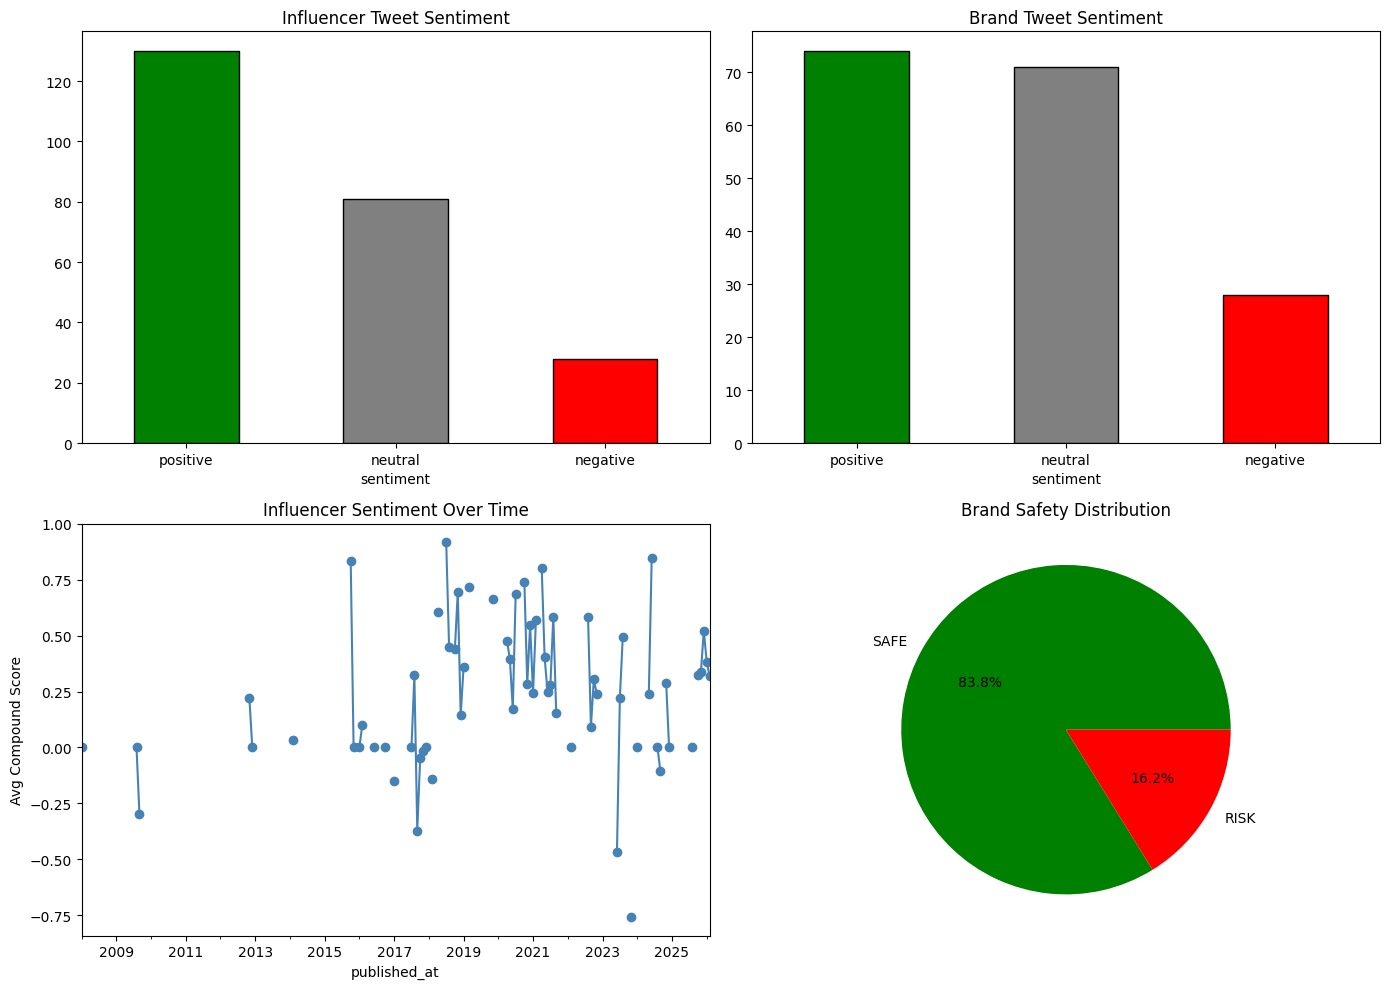

 Plot saved!


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

tw_matched['sentiment'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['green', 'gray', 'red'], edgecolor='black')
axes[0,0].set_title('Influencer Tweet Sentiment')
axes[0,0].tick_params(axis='x', rotation=0)

tw_brands['sentiment'].value_counts().plot(kind='bar', ax=axes[0,1],
    color=['green', 'gray', 'red'], edgecolor='black')
axes[0,1].set_title('Brand Tweet Sentiment')
axes[0,1].tick_params(axis='x', rotation=0)

tw_matched['published_at'] = pd.to_datetime(tw_matched['published_at'], utc=True)
tw_matched.set_index('published_at')['compound'].resample('ME').mean().plot(
    ax=axes[1,0], marker='o', color='steelblue')
axes[1,0].set_title('Influencer Sentiment Over Time')
axes[1,0].set_ylabel('Avg Compound Score')

tw_brands['brand_safety_flag'].value_counts().plot(kind='pie', ax=axes[1,1],
    colors=['green', 'red'], autopct='%1.1f%%')
axes[1,1].set_title('Brand Safety Distribution')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CAPSTONE_DATA/outputs/twitter_sentiment_plot.png')
plt.show()
print(" Plot saved!")

In [14]:
tw_matched.to_csv('/content/drive/MyDrive/CAPSTONE_DATA/outputs/twitter_influencer_with_sentiment.csv', index=False)
tw_brands.to_csv('/content/drive/MyDrive/CAPSTONE_DATA/outputs/twitter_brands_with_sentiment.csv', index=False)

print(" Both saved!")
print(f"Influencer tweets: {tw_matched.shape}")
print(f"Brand tweets: {tw_brands.shape}")

 Both saved!
Influencer tweets: (239, 19)
Brand tweets: (173, 21)
